In [1]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk"
os.environ["PYSPARK_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
spark = SparkSession.builder \
    .appName("IDS2018") \
    .master("spark://lattitude7420:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.cores", "2") \
    .config("spark.memory.fraction", "0.6") \
    .config("spark.memory.storageFraction", "0.3") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/11 00:06:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
print("UI:", spark.sparkContext.uiWebUrl)

Spark: 3.5.8
UI: http://lattitude7420:4040


### Load Data

In [10]:
HDFS = "hdfs://lattitude7420:9000/ids2018/raw"

df_tue = spark.read.csv(
    f"{HDFS}/Tuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    header=True, inferSchema=False
).sample(fraction=0.1, seed=42)

df_rest = spark.read.csv([
    f"{HDFS}/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    f"{HDFS}/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
], header=True, inferSchema=False)

extra_cols = ["Flow ID", "Src IP", "Src Port", "Dst IP"]
df_tue = df_tue.drop(*extra_cols)

df = df_rest.union(df_tue)
print(f"Raw rows (before cleaning): {df.count():,}")

[Stage 12:======================================================> (53 + 1) / 54]

Raw rows (before cleaning): 9,078,330


### CLEAN COLUMN NAMES + DROP HEADER LEAKS

In [12]:
df = df.toDF(*[c.strip() for c in df.columns])
df = df.filter(F.col("Label") != "Label")
print(f"Raw rows (mid cleaning): {df.count():,}")

[Stage 15:=====================================================>  (52 + 2) / 54]

Raw rows (mid cleaning): 9,078,271


### CAST TO FLOAT + DROP INF/NULL

In [14]:
from pyspark.sql.functions import to_timestamp, hour, dayofweek

df = df.toDF(*[c.strip() for c in df.columns])
df = df.filter(F.col("Label") != "Label")

# Extract time features before dropping Timestamp
df = df.withColumn("ts", to_timestamp(F.col("Timestamp"), "dd/MM/yyyy HH:mm:ss"))
df = df.withColumn("hour_of_day", hour(F.col("ts")).cast(FloatType()))
df = df.withColumn("day_of_week", dayofweek(F.col("ts")).cast(FloatType()))
df = df.drop("Timestamp", "ts")

# Only cast numeric columns to float
non_numeric = ["Label"]
label_col = "Label"
feature_cols = [c for c in df.columns if c not in non_numeric]

for col in feature_cols:
    df = df.withColumn(col, df[col].cast(FloatType()))

# Replace Inf → null → drop
df = df.replace(float('inf'), None)
df = df.replace(float('-inf'), None)
df = df.dropna()

print(f"Rows after cleaning: {df.count():,}")

[Stage 19:======================================================> (53 + 1) / 54]

Rows after cleaning: 9,036,125


### FEATURE ENGINEERING

In [15]:
df = df.withColumn("log_flow_duration",
        F.log1p(F.col("Flow Duration")))
df = df.withColumn("pkt_ratio",
        F.col("Tot Fwd Pkts") / (F.col("Tot Bwd Pkts") + 1))
df = df.withColumn("byte_ratio",
        F.col("TotLen Fwd Pkts") / (F.col("TotLen Bwd Pkts") + 1))

# Drop INF-prone columns
df = df.drop("Flow Byts/s", "Flow Pkts/s")

### LABEL ENGINEERING

In [16]:
df = df.withColumn("Label", F.trim(F.col("Label")))

# Binary: Benign=0, Attack=1
df = df.withColumn("binary_label",
    F.when(F.col("Label") == "Benign", 0.0).otherwise(1.0))

# Multiclass: merge tiny/related classes
df = df.withColumn("attack_type",
    F.when(F.col("Label") == "Benign", "Benign")
     .when(F.col("Label").isin(
         "DDOS attack-HOIC", "DDOS attack-LOIC-UDP", "DDoS attacks-LOIC-HTTP"
     ), "DDoS")
     .when(F.col("Label").isin(
         "DoS attacks-Hulk", "DoS attacks-SlowHTTPTest",
         "DoS attacks-GoldenEye", "DoS attacks-Slowloris"
     ), "DoS")
     .when(F.col("Label").isin(
         "Brute Force -Web", "Brute Force -XSS", "SQL Injection"
     ), "WebAttack")
     .otherwise(F.col("Label"))  # Bot, FTP-BruteForce, SSH-Bruteforce, Infilteration
)

# Verify distribution
print("Label distribution:")
df.groupBy("attack_type").count().orderBy("count", ascending=False).show()

# Cache — we reuse df many times
df.cache()

Label distribution:


+--------------+-------+
|   attack_type|  count|
+--------------+-------+
|        Benign|6807784|
|          DDoS| 745340|
|           DoS| 654300|
|           Bot| 286191|
|FTP-BruteForce| 193354|
|SSH-Bruteforce| 187589|
| Infilteration| 160639|
|     WebAttack|    928|
+--------------+-------+



DataFrame[Dst Port: float, Protocol: float, Flow Duration: float, Tot Fwd Pkts: float, Tot Bwd Pkts: float, TotLen Fwd Pkts: float, TotLen Bwd Pkts: float, Fwd Pkt Len Max: float, Fwd Pkt Len Min: float, Fwd Pkt Len Mean: float, Fwd Pkt Len Std: float, Bwd Pkt Len Max: float, Bwd Pkt Len Min: float, Bwd Pkt Len Mean: float, Bwd Pkt Len Std: float, Flow IAT Mean: float, Flow IAT Std: float, Flow IAT Max: float, Flow IAT Min: float, Fwd IAT Tot: float, Fwd IAT Mean: float, Fwd IAT Std: float, Fwd IAT Max: float, Fwd IAT Min: float, Bwd IAT Tot: float, Bwd IAT Mean: float, Bwd IAT Std: float, Bwd IAT Max: float, Bwd IAT Min: float, Fwd PSH Flags: float, Bwd PSH Flags: float, Fwd URG Flags: float, Bwd URG Flags: float, Fwd Header Len: float, Bwd Header Len: float, Fwd Pkts/s: float, Bwd Pkts/s: float, Pkt Len Min: float, Pkt Len Max: float, Pkt Len Mean: float, Pkt Len Std: float, Pkt Len Var: float, FIN Flag Cnt: float, SYN Flag Cnt: float, RST Flag Cnt: float, PSH Flag Cnt: float, ACK Fl

### EDA PLOTS

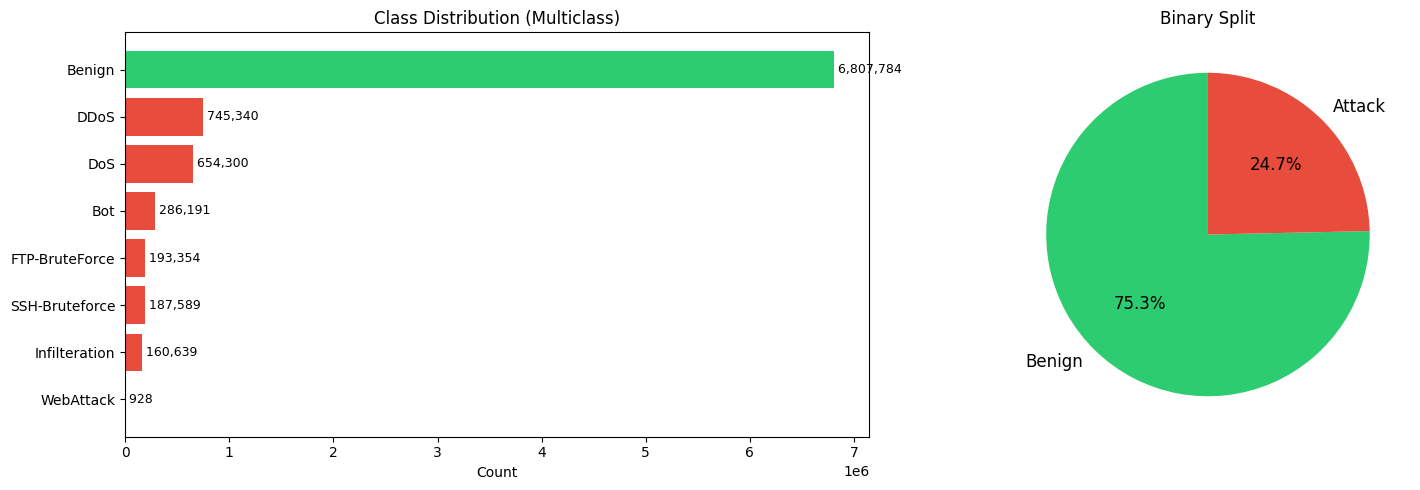

In [18]:
dist_pd = df.groupBy("attack_type").count() \
             .orderBy("count", ascending=False).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#2ecc71' if x == 'Benign' else '#e74c3c' for x in dist_pd['attack_type']]
axes[0].barh(dist_pd['attack_type'], dist_pd['count'], color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Class Distribution (Multiclass)')
axes[0].invert_yaxis()
for i, v in enumerate(dist_pd['count']):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=9)

binary_pd = df.groupBy("binary_label").count().toPandas()
axes[1].pie(binary_pd['count'],
            labels=['Benign','Attack'],
            colors=['#2ecc71','#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Binary Split')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Train/Test Split

In [19]:
train, test = df.randomSplit([0.8, 0.2], seed=42)
train.cache()
test.cache()
print(f"Train: {train.count():,} | Test: {test.count():,}")

[Stage 45:====================================================>   (51 + 2) / 54]

Train: 7,229,310 | Test: 1,806,815


### Save split to HDFS

In [20]:
train.write.mode("overwrite").parquet("hdfs://lattitude7420:9000/ids2018/train")
test.write.mode("overwrite").parquet("hdfs://lattitude7420:9000/ids2018/test")
print("Train and test saved to HDFS!")

# Verify
print("Train parquet size:")
import subprocess
result = subprocess.run(
    ["hdfs", "dfs", "-du", "-s", "-h", "hdfs://lattitude7420:9000/ids2018/train"],
    capture_output=True, text=True
)
print(result.stdout)

Train and test saved to HDFS!
Train parquet size:
481.1 M  962.1 M  hdfs://lattitude7420:9000/ids2018/train



### Load Test Train from HDFS

In [5]:
train = spark.read.parquet("hdfs://lattitude7420:9000/ids2018/train")
test  = spark.read.parquet("hdfs://lattitude7420:9000/ids2018/test")
train.cache()
test.cache()

26/05/11 00:07:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


DataFrame[Dst Port: float, Protocol: float, Flow Duration: float, Tot Fwd Pkts: float, Tot Bwd Pkts: float, TotLen Fwd Pkts: float, TotLen Bwd Pkts: float, Fwd Pkt Len Max: float, Fwd Pkt Len Min: float, Fwd Pkt Len Mean: float, Fwd Pkt Len Std: float, Bwd Pkt Len Max: float, Bwd Pkt Len Min: float, Bwd Pkt Len Mean: float, Bwd Pkt Len Std: float, Flow IAT Mean: float, Flow IAT Std: float, Flow IAT Max: float, Flow IAT Min: float, Fwd IAT Tot: float, Fwd IAT Mean: float, Fwd IAT Std: float, Fwd IAT Max: float, Fwd IAT Min: float, Bwd IAT Tot: float, Bwd IAT Mean: float, Bwd IAT Std: float, Bwd IAT Max: float, Bwd IAT Min: float, Fwd PSH Flags: float, Bwd PSH Flags: float, Fwd URG Flags: float, Bwd URG Flags: float, Fwd Header Len: float, Bwd Header Len: float, Fwd Pkts/s: float, Bwd Pkts/s: float, Pkt Len Min: float, Pkt Len Max: float, Pkt Len Mean: float, Pkt Len Std: float, Pkt Len Var: float, FIN Flag Cnt: float, SYN Flag Cnt: float, RST Flag Cnt: float, PSH Flag Cnt: float, ACK Fl

### STRATIFIED UNDERSAMPLE TRAIN ONLY
#### Keep all attacks, sample benign to 2:1 ratio (benign:attack)

In [6]:
train_attack = train.filter(F.col("binary_label") == 1.0)
train_benign = train.filter(F.col("binary_label") == 0.0)

n_attacks = train_attack.count()
n_benign  = train_benign.count()
fraction  = min((n_attacks * 2.0) / n_benign, 1.0)

print(f"Attacks in train : {n_attacks:,}")
print(f"Benign in train  : {n_benign:,}")
print(f"Benign sample fraction: {fraction:.4f}")

train_benign_sampled = train_benign.sample(fraction=fraction, seed=42)
train_balanced = train_attack.union(train_benign_sampled)
train_balanced.cache()

total = train_balanced.count()
print(f"Balanced train   : {total:,}")

Attacks in train : 1,782,733
Benign in train  : 5,446,577
Benign sample fraction: 0.6546
Balanced train   : 5,348,848


### Build Feature Vector

In [7]:
eng_cols = ["log_flow_duration", "pkt_ratio", "byte_ratio", "hour_of_day", "day_of_week"]
exclude = ["Label", "binary_label", "attack_type", "Flow Byts/s", "Flow Pkts/s"]
final_features = [c for c in train.columns if c not in exclude] + eng_cols

# Remove duplicates while preserving order
seen = set()
final_features = [c for c in final_features
                  if not (c in seen or seen.add(c))]

print(f"Total features: {len(final_features)}")
print(final_features)

assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="raw_features",
    handleInvalid="skip"
)
scaler = StandardScaler(inputCol="raw_features", outputCol="features")

Total features: 81
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b A

### Train Binary Model

In [8]:
rf_binary = RandomForestClassifier(
    labelCol="binary_label",
    featuresCol="features",
    numTrees=20,
    maxDepth=8,
    maxBins=32,
    subsamplingRate=0.8,
    seed=42
)
pipeline_binary = Pipeline(stages=[assembler, scaler, rf_binary])

print("Training binary model...")
model_binary = pipeline_binary.fit(train_balanced)
print("Binary model done!")

Training binary model...
Binary model done!


### Save Binary Model

In [9]:
model_binary.write().overwrite().save(
    "hdfs://lattitude7420:9000/ids2018/models/binary"
)
print("Saved!")

Saved!


### Undersample for Multiclass

In [10]:
train_attack_mc = train.filter(F.col("attack_type") != "Benign")
train_benign_mc = train.filter(F.col("attack_type") == "Benign")

n_attacks_mc = train_attack_mc.count()
fraction_mc  = min((n_attacks_mc * 2.0) / train_benign_mc.count(), 1.0)

train_benign_mc_sampled = train_benign_mc.sample(fraction=fraction_mc, seed=42)
train_mc_balanced = train_attack_mc.union(train_benign_mc_sampled)
train_mc_balanced.cache()
print(f"Balanced multiclass train: {train_mc_balanced.count():,}")

Balanced multiclass train: 5,348,848


### Train Multiclass Model

In [11]:
indexer = StringIndexer(
    inputCol="attack_type",
    outputCol="mc_label",
    handleInvalid="keep"
)
rf_multi = RandomForestClassifier(
    labelCol="mc_label",
    featuresCol="features",
    numTrees=20,
    maxDepth=8,
    maxBins=32,
    subsamplingRate=0.8,
    seed=42
)
pipeline_multi = Pipeline(stages=[assembler, scaler, indexer, rf_multi])

print("Training multiclass model...")
model_multi = pipeline_multi.fit(train_mc_balanced)
print("Multiclass model done!")

Training multiclass model...
Multiclass model done!


### Save Multiclass Model

In [12]:
model_multi.write().overwrite().save(
    "hdfs://lattitude7420:9000/ids2018/models/multiclass"
)
print("Saved!")

Saved!


### Load models

In [8]:
model_binary = PipelineModel.load("hdfs://lattitude7420:9000/ids2018/models/binary")
model_multi  = PipelineModel.load("hdfs://lattitude7420:9000/ids2018/models/multiclass")
print("Both models loaded!")

26/05/11 00:09:25 WARN TaskSetManager: Lost task 0.0 in stage 40.0 (TID 42) (192.168.0.203 executor 4): java.io.IOException: Cannot run program "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3": error=2, No such file or directory
	at java.base/java.lang.ProcessBuilder.start(ProcessBuilder.java:1128)
	at java.base/java.lang.ProcessBuilder.start(ProcessBuilder.java:1071)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.

Both models loaded!


### Generate Predictions

In [9]:
print("Binary predictions")
pred_binary = model_binary.transform(test)
pred_binary.cache()

print("Multiclass predictions")
pred_multi = model_multi.transform(test)
pred_multi.cache()


Binary predictions
Multiclass predictions


DataFrame[Dst Port: float, Protocol: float, Flow Duration: float, Tot Fwd Pkts: float, Tot Bwd Pkts: float, TotLen Fwd Pkts: float, TotLen Bwd Pkts: float, Fwd Pkt Len Max: float, Fwd Pkt Len Min: float, Fwd Pkt Len Mean: float, Fwd Pkt Len Std: float, Bwd Pkt Len Max: float, Bwd Pkt Len Min: float, Bwd Pkt Len Mean: float, Bwd Pkt Len Std: float, Flow IAT Mean: float, Flow IAT Std: float, Flow IAT Max: float, Flow IAT Min: float, Fwd IAT Tot: float, Fwd IAT Mean: float, Fwd IAT Std: float, Fwd IAT Max: float, Fwd IAT Min: float, Bwd IAT Tot: float, Bwd IAT Mean: float, Bwd IAT Std: float, Bwd IAT Max: float, Bwd IAT Min: float, Fwd PSH Flags: float, Bwd PSH Flags: float, Fwd URG Flags: float, Bwd URG Flags: float, Fwd Header Len: float, Bwd Header Len: float, Fwd Pkts/s: float, Bwd Pkts/s: float, Pkt Len Min: float, Pkt Len Max: float, Pkt Len Mean: float, Pkt Len Std: float, Pkt Len Var: float, FIN Flag Cnt: float, SYN Flag Cnt: float, RST Flag Cnt: float, PSH Flag Cnt: float, ACK Fl

### Binary Metrics 

In [10]:
auc  = BinaryClassificationEvaluator(
           labelCol="binary_label",
           metricName="areaUnderROC").evaluate(pred_binary)
f1   = MulticlassClassificationEvaluator(
           labelCol="binary_label",
           metricName="f1").evaluate(pred_binary)
acc  = MulticlassClassificationEvaluator(
           labelCol="binary_label",
           metricName="accuracy").evaluate(pred_binary)
prec = MulticlassClassificationEvaluator(
           labelCol="binary_label",
           metricName="weightedPrecision").evaluate(pred_binary)
rec  = MulticlassClassificationEvaluator(
           labelCol="binary_label",
           metricName="weightedRecall").evaluate(pred_binary)

print("="*40)
print("       BINARY RESULTS")
print("="*40)
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  F1        : {f1:.4f}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print("="*40)

[Stage 97:==================================================>     (10 + 1) / 11]

       BINARY RESULTS
  AUC-ROC   : 0.9851
  F1        : 0.9806
  Accuracy  : 0.9808
  Precision : 0.9810
  Recall    : 0.9808


### Multiclass Metrics

In [11]:
mc_f1   = MulticlassClassificationEvaluator(
              labelCol="mc_label",
              metricName="f1").evaluate(pred_multi)
mc_acc  = MulticlassClassificationEvaluator(
              labelCol="mc_label",
              metricName="accuracy").evaluate(pred_multi)
mc_prec = MulticlassClassificationEvaluator(
              labelCol="mc_label",
              metricName="weightedPrecision").evaluate(pred_multi)
mc_rec  = MulticlassClassificationEvaluator(
              labelCol="mc_label",
              metricName="weightedRecall").evaluate(pred_multi)

print("="*40)
print("     MULTICLASS RESULTS")
print("="*40)
print(f"  F1        : {mc_f1:.4f}")
print(f"  Accuracy  : {mc_acc:.4f}")
print(f"  Precision : {mc_prec:.4f}")
print(f"  Recall    : {mc_rec:.4f}")
print("="*40)

[Stage 106:=============================================>          (9 + 2) / 11]

     MULTICLASS RESULTS
  F1        : 0.9721
  Accuracy  : 0.9807
  Precision : 0.9801
  Recall    : 0.9807


### Confusion Matrices

#### Binary

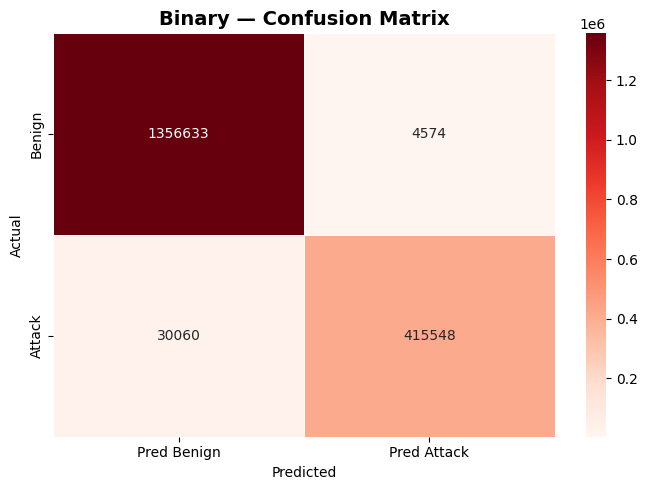

In [12]:
cm = pred_binary.groupBy("binary_label", "prediction").count().toPandas()
cm_pivot = cm.pivot(index="binary_label", columns="prediction", values="count").fillna(0)
cm_pivot.index   = ['Benign', 'Attack']
cm_pivot.columns = ['Pred Benign', 'Pred Attack']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5)
plt.title('Binary — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_binary.png', dpi=150, bbox_inches='tight')
plt.show()

#### Multiclass 

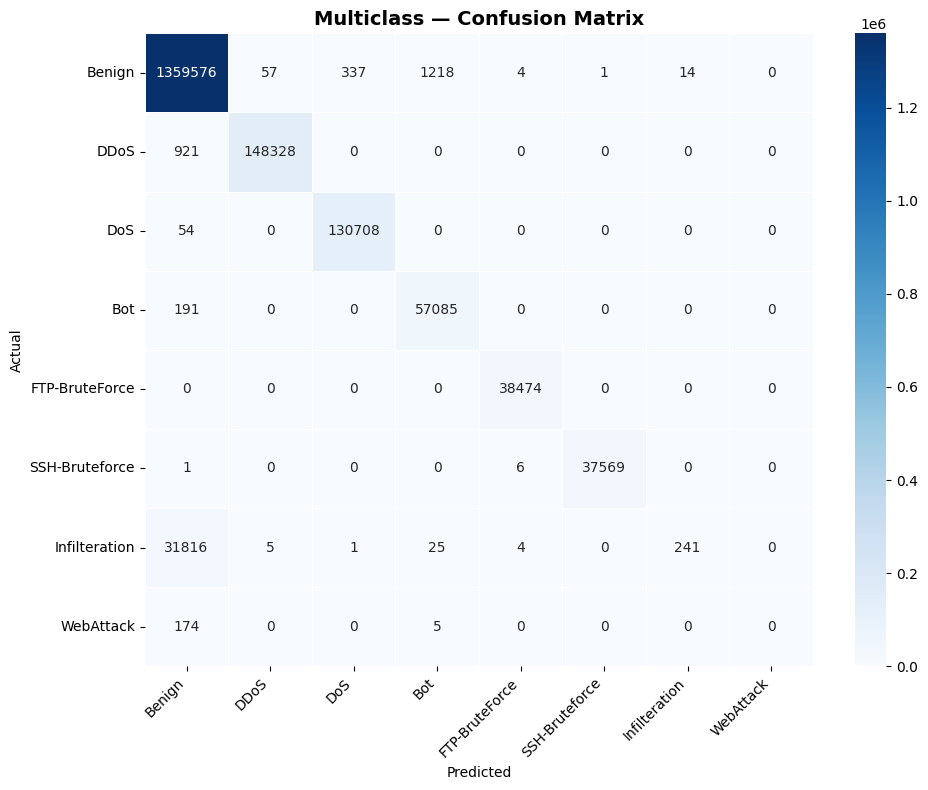

In [13]:
labels = model_multi.stages[2].labels
n = len(labels)

cm_multi = pred_multi.groupBy("mc_label", "prediction").count().toPandas()
cm_matrix = np.zeros((n, n))
for _, row in cm_multi.iterrows():
    i, j = int(row['mc_label']), int(row['prediction'])
    if i < n and j < n:
        cm_matrix[i][j] = row['count']

plt.figure(figsize=(10, 8))
sns.heatmap(cm_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
plt.title('Multiclass — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

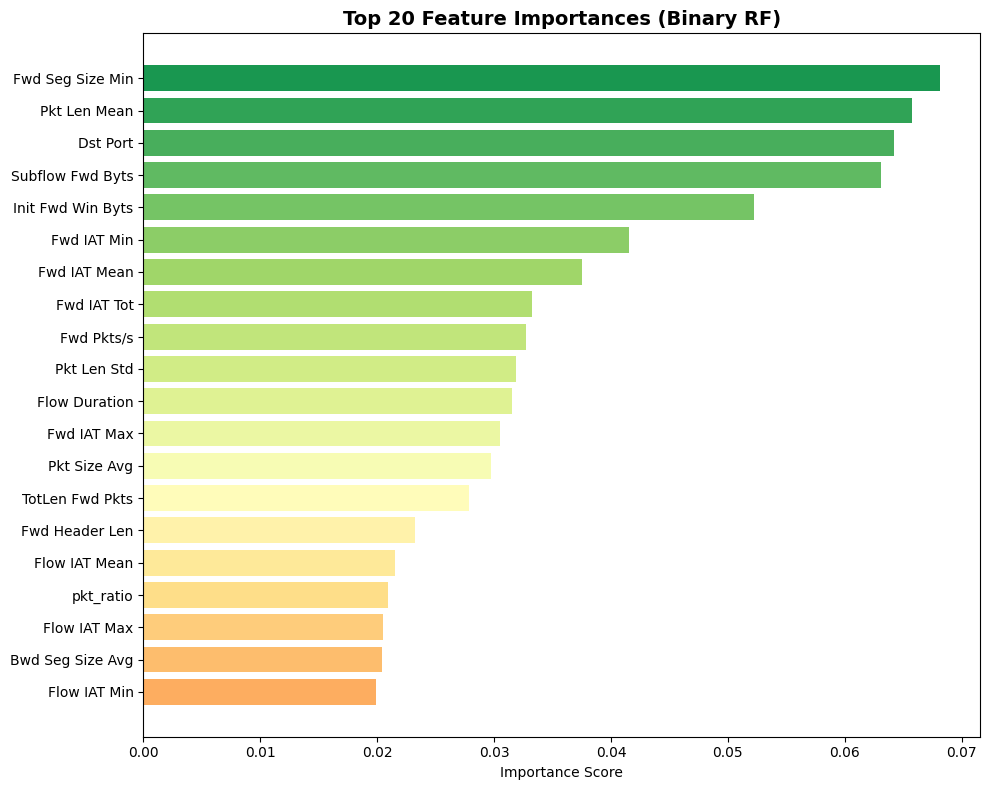

In [14]:
rf_model = model_binary.stages[-1]
assembler = model_binary.stages[0]
feature_names = assembler.getInputCols()
importances = rf_model.featureImportances.toArray()

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['feature'][::-1], feat_df['importance'][::-1],
         color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20)))
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances (Binary RF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Per-class Metric

         Class  Precision  Recall     F1
        Benign     0.9762  0.9988 0.9874
          DDoS     0.9996  0.9938 0.9967
           DoS     0.9974  0.9996 0.9985
           Bot     0.9786  0.9967 0.9876
FTP-BruteForce     0.9996  1.0000 0.9998
SSH-Bruteforce     1.0000  0.9998 0.9999
 Infilteration     0.9451  0.0075 0.0149
     WebAttack     0.0000  0.0000 0.0000


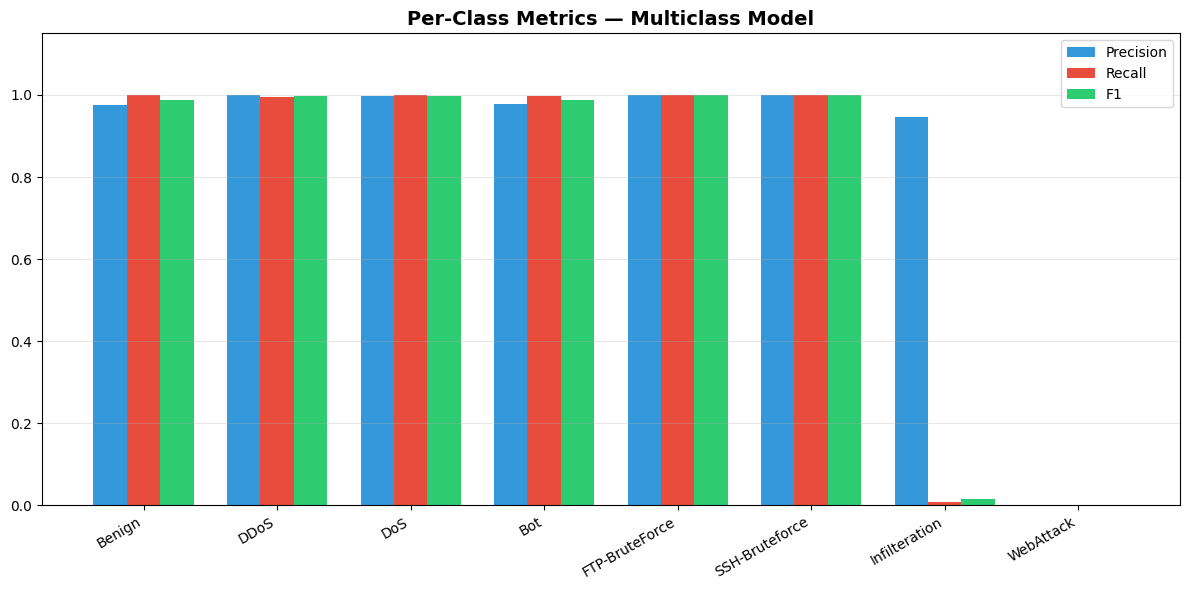

In [16]:
labels = model_multi.stages[2].labels

# Compute per-class metrics directly from confusion matrix
cm_multi = pred_multi.groupBy("mc_label", "prediction").count().toPandas()
n = len(labels)
cm_matrix = np.zeros((n, n))
for _, row in cm_multi.iterrows():
    i, j = int(row['mc_label']), int(row['prediction'])
    if i < n and j < n:
        cm_matrix[i][j] = row['count']

rows = []
for i, name in enumerate(labels):
    tp = cm_matrix[i][i]
    fp = cm_matrix[:, i].sum() - tp
    fn = cm_matrix[i, :].sum() - tp
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    rows.append({
        'Class':     name,
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1':        round(f1, 4)
    })

per_class_df = pd.DataFrame(rows)
print(per_class_df.to_string(index=False))

# Plot
x = np.arange(len(per_class_df))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w, per_class_df['Precision'], w, label='Precision', color='#3498db')
ax.bar(x,     per_class_df['Recall'],    w, label='Recall',    color='#e74c3c')
ax.bar(x + w, per_class_df['F1'],        w, label='F1',        color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(per_class_df['Class'], rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Metrics — Multiclass Model', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()